In [1]:
import uproot
import ROOT
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak

In [2]:
POT_MC = 2.43007e+20
POT_OFFBEAM = 2.11e+20
POT_WIREMOD = 1.03135e+21
#1.03135e+21

In [3]:
NBINS = 50
ANGLE_CUT = 90
HIGH_X = 30

In [4]:
NBINS_DEPE = 50
HIGH_DEPE = 200

In [5]:
NBINS_CHI2 = 50
HIGH_CHI2 = 50

In [6]:
particle = "_protons"
#particle = "_mu"
cut = ""

In [7]:
#mode_vars = ['STANDARD']
#mode_vars = ['GAIN','BETA','ALPHA','R', 'STANDARD', f'WIREMOD{cut}']
#var_color = ['blue','deepskyblue','darkgreen','lime','red','orange','purple','pink','gray', 'gold']

#mode_vars = ['GAIN','BETA','ALPHA','R','STANDARD']
#var_color = ['blue','deepskyblue','darkgreen','lime','red','orange','purple','pink','gray']

mode_vars = ['GAIN','STANDARD']
var_color = ['blue','deepskyblue','gray']

In [ ]:
for RR in range(0,25) :

    fig = plt.figure()

    gs = fig.add_gridspec(2, 1, height_ratios=[8,2], hspace=0)

    print('RR interval: [',RR,RR+1,')')

    filename = f'varMC_DATA{cut}.root'
    file = uproot.open(filename)
    tree = file['tree']
    print("num entries:", tree.num_entries)
    print("keys:", tree.keys())
    arrays = tree.arrays(
            ["slice/_protons/_protons._dedx", 
            "slice/_protons/_protons._rr",
            "slice/_mu/_mu._dedx", 
            "slice/_mu/_mu._rr",
            "slice/_protons/_protons._theta_xw",
            "slice/_mu/_mu._theta_xw"],
            library="ak"
            )

    theta_broadcast, _ = ak.broadcast_arrays(arrays[f"slice/{particle}/{particle}._theta_xw"], arrays[f"slice/{particle}/{particle}._dedx"])

    rr_flat   = ak.to_numpy(ak.flatten(arrays[f"slice/{particle}/{particle}._rr"], axis=None))
    dedx_flat = ak.to_numpy(ak.flatten(arrays[f"slice/{particle}/{particle}._dedx"], axis=None))
    theta_flat = ak.to_numpy(ak.flatten(theta_broadcast, axis=None))
    mask = (rr_flat >= RR) & (rr_flat < RR + 1) & (np.abs(theta_flat)*180/np.pi < ANGLE_CUT)
    dedx_thisRR = dedx_flat[mask]

    print('DATA: ',len(dedx_thisRR),'hits')
    
    h_data = ROOT.TH1D(f"h_data_rr{RR}","",NBINS,0,HIGH_X)
    h_data.Sumw2()
    data_np = np.array(dedx_thisRR)
    #h_data.FillN(data_np.size,data_np,np.ones_like(data_np))
    for hit_data in data_np : h_data.Fill(hit_data)

    h_data.Scale(1. / h_data.Integral("width"))

    bin_centers_DATA = []
    counts_DATA = []
    errors_DATA = []

    for bin in range(1,NBINS + 1):
        bin_centers_DATA.append(h_data.GetBinCenter(bin))
        counts_DATA.append(h_data.GetBinContent(bin))
        errors_DATA.append(h_data.GetBinError(bin))


    filename = f'varMC_OFFBEAM{cut}.root'
    file = uproot.open(filename)
    tree = file['tree']
    arrays = tree.arrays(
            ["slice/_protons/_protons._dedx", 
            "slice/_protons/_protons._rr",
            "slice/_mu/_mu._dedx", 
            "slice/_mu/_mu._rr",
            "slice/_protons/_protons._theta_xw",
            "slice/_mu/_mu._theta_xw"],
            library="ak"
            )
    
    theta_broadcast, _ = ak.broadcast_arrays(arrays[f"slice/{particle}/{particle}._theta_xw"], arrays[f"slice/{particle}/{particle}._dedx"])

    rr_flat   = ak.to_numpy(ak.flatten(arrays[f"slice/{particle}/{particle}._rr"],   axis=None))
    dedx_flat = ak.to_numpy(ak.flatten(arrays[f"slice/{particle}/{particle}._dedx"], axis=None))
    theta_flat = ak.to_numpy(ak.flatten(theta_broadcast, axis=None))
    mask = (rr_flat >= RR) & (rr_flat < RR+1) & (np.abs(theta_flat)*180/np.pi < ANGLE_CUT)
    dedx_thisRR_offbeam = dedx_flat[mask]
    weights_OFFBEAM_dedx = np.full(len(dedx_thisRR_offbeam), 1. / POT_OFFBEAM)

    print('OFFBEAM: ',len(dedx_thisRR_offbeam),'hits')

    plt.subplot(gs[0])
    plt.errorbar(bin_centers_DATA,counts_DATA,yerr=errors_DATA,fmt='o', ms=3.5, capsize=1.5, capthick=1.5, elinewidth=1.5, color = 'black', label = 'DATA')

    m = -1
    for mode in mode_vars:

        for n,sigma in enumerate(['_plus1sigma','_minus1sigma']):

            if (n == 0 and mode == 'STANDARD') or (n == 0 and mode == f'WIREMOD{cut}') : continue
            if (n == 1 and mode == 'STANDARD') or (n == 1 and mode == f'WIREMOD{cut}') : sigma = ''

            m = m+1

            filename = f'varMC_{mode}{sigma}.root'

            print(filename)

            file = uproot.open(filename)

            tree = file['tree']
            #print(tree.keys())

            arrays = tree.arrays(
            ["slice/_protons/_protons._dedx", 
            "slice/_protons/_protons._rr",
            "slice/_mu/_mu._dedx", 
            "slice/_mu/_mu._rr",
            "slice/_protons/_protons._theta_xw",
            "slice/_mu/_mu._theta_xw"],
            library="ak"
            )

            theta_broadcast, _ = ak.broadcast_arrays(arrays[f"slice/{particle}/{particle}._theta_xw"], arrays[f"slice/{particle}/{particle}._dedx"])

            rr_flat   = ak.to_numpy(ak.flatten(arrays[f"slice/{particle}/{particle}._rr"], axis=None))
            dedx_flat = ak.to_numpy(ak.flatten(arrays[f"slice/{particle}/{particle}._dedx"], axis=None))
            theta_flat = ak.to_numpy(ak.flatten(theta_broadcast, axis=None))
            mask = (rr_flat >= RR) & (rr_flat < RR + 1) & (np.abs(theta_flat)*180/np.pi < ANGLE_CUT)
            dedx_thisRR = dedx_flat[mask]
            POT = 0
            if mode == f"WIREMOD{cut}" : POT = POT_WIREMOD 
            else : POT = POT_MC
            weights_MC_dedx = np.full(len(dedx_thisRR), 1. / POT)

            print(f'MC {mode}: ',len(dedx_thisRR),'hits')

            mc_off = np.concatenate([dedx_thisRR, dedx_thisRR_offbeam])
            weights_mc_off = np.concatenate([weights_MC_dedx, weights_OFFBEAM_dedx])
            n_mc_off, bins = np.histogram(
            mc_off,
            bins=NBINS,
            range=(0, HIGH_X),
            weights=weights_mc_off,
            density=True
            )

            print(f'MC {mode}: [',n_mc_off,']')

            bin_centers = 0.5 * (bins[:-1] + bins[1:])
            bin_widths = np.diff(bins)

            ratio = np.zeros_like(counts_DATA)
            ratio_err = np.zeros_like(counts_DATA)

            for k in range(len(counts_DATA)):
                if n_mc_off[k] > 0:
                    ratio[k] = counts_DATA[k] / n_mc_off[k]

            sigma_n = 0
            if sigma == '_plus1sigma' : sigma_n = 1
            elif sigma == '_minus1sigma' : sigma_n = -1

            plt.subplot(gs[0])

            lls = "-"
            llw = 2
            if mode == 'STANDARD' : 
                lls = '--'
                llw = 3
            
            plt.hist(mc_off, bins=NBINS, range=(0, HIGH_X), weights=weights_mc_off, density=True, histtype='step', lw=llw, ls=lls, label=fr'MC var {mode} ${sigma_n}\sigma$', color = var_color[m], alpha = 0.8)
            plt.setp(plt.gca().get_xticklabels(), visible=False)
            plt.gca().tick_params(labelbottom=False)
            ax = plt.gca()
            yticks = ax.get_yticks()
            # keep only ticks strictly greater than the axis minimum, so the bottom one is dropped
            ax.set_yticks(yticks[yticks > ax.get_ylim()[0]])
            plt.ylabel('entries (area norm.)', fontsize=14)
            plt.yticks(fontsize=14)

            plt.title('dE/dx for RR bin [{},{}) cm'.format(RR,RR+1), fontsize=18)

            plt.subplot(gs[1])

            dx = bin_centers[1] - bin_centers[0]

            edges = np.concatenate([
            [bin_centers[0] - dx/2],
            bin_centers[:-1] + dx/2,
            [bin_centers[-1] + dx/2]
            ])

            plt.stairs(ratio,edges,fill=False,lw=2,color=var_color[m])

            plt.fill_between(
            edges[:-1],
            1,
            ratio,
            step='post',
            alpha=0.4,
            color=var_color[m],
            lw=0
            )

            plt.axhline(1.0, color='black', linestyle='--')

            plt.xlabel('dE/dx [MeV/cm]', fontsize=14)
            plt.ylabel(r'$\frac{DATA}{MC}$', fontsize=14)
            plt.xticks(fontsize=14, rotation=60)
            plt.yticks(fontsize=14)
            plt.ylim(0,2)


    plt.subplot(gs[0])  
    plt.legend(loc='upper right',fontsize = 6, ncols = 1)
    plt.savefig(f'DEDX_VAR/rr{RR}_anglecut_{ANGLE_CUT}{particle}_WIREMOD_CUT.pdf',format='pdf',bbox_inches='tight')



        


In [ ]:

fig = plt.figure()

gs = fig.add_gridspec(2, 1, height_ratios=[8,2], hspace=0)

filename = f'varMC_DATA{cut}.root'
file = uproot.open(filename)
tree = file['tree']
print("num entries:", tree.num_entries)
print("keys:", tree.keys())
arrays = tree.arrays(
        ["slice/_protons/_protons._dedx", 
        "slice/_protons/_protons._rr",
        "slice/_mu/_mu._dedx", 
        "slice/_mu/_mu._rr",
        "slice/_protons/_protons._theta_xw",
        "slice/_mu/_mu._theta_xw",
        "slice/_protons/_protons._depE",
        "slice/_mu/_mu._depE"],
        library="ak"
        )

depE = ak.to_numpy(ak.flatten(arrays[f"slice/{particle}/{particle}._depE"], axis=None))
    
h_data = ROOT.TH1D("h_data_depE","",NBINS_DEPE,0,HIGH_DEPE)
h_data.Sumw2()
data_np = np.array(depE)
for hit_data in data_np : h_data.Fill(hit_data)

h_data.Scale(1. / h_data.Integral("width"))

bin_centers_DATA = []
counts_DATA = []
errors_DATA = []

for bin in range(1,NBINS_DEPE + 1):
    bin_centers_DATA.append(h_data.GetBinCenter(bin))
    counts_DATA.append(h_data.GetBinContent(bin))
    errors_DATA.append(h_data.GetBinError(bin))


filename = f'varMC_OFFBEAM{cut}.root'
file = uproot.open(filename)
tree = file['tree']
arrays = tree.arrays(
        ["slice/_protons/_protons._dedx", 
        "slice/_protons/_protons._rr",
        "slice/_mu/_mu._dedx", 
        "slice/_mu/_mu._rr",
        "slice/_protons/_protons._theta_xw",
        "slice/_mu/_mu._theta_xw",
        "slice/_protons/_protons._depE",
        "slice/_mu/_mu._depE"],
        library="ak"
        )

depE_offbeam = ak.to_numpy(ak.flatten(arrays[f"slice/{particle}/{particle}._depE"], axis=None))

weights_OFFBEAM_depE = np.full(len(depE_offbeam), 1. / POT_OFFBEAM)

plt.subplot(gs[0])
plt.errorbar(bin_centers_DATA,counts_DATA,yerr=errors_DATA,fmt='o', ms=3.5, capsize=1.5, capthick=1.5, elinewidth=1.5, color = 'black', label = 'DATA')

m = -1
for mode in mode_vars:

    for n,sigma in enumerate(['_plus1sigma','_minus1sigma']):

        if (n == 0 and mode == 'STANDARD') or (n == 0 and mode == f'WIREMOD{cut}') : continue
        if (n == 1 and mode == 'STANDARD') or (n == 1 and mode == f'WIREMOD{cut}') : sigma = ''

        m = m+1

        filename = f'varMC_{mode}{sigma}.root'

        print(filename)

        file = uproot.open(filename)

        tree = file['tree']
        #print(tree.keys())

        arrays = tree.arrays(
        ["slice/_protons/_protons._dedx", 
        "slice/_protons/_protons._rr",
        "slice/_mu/_mu._dedx", 
        "slice/_mu/_mu._rr",
        "slice/_protons/_protons._theta_xw",
        "slice/_mu/_mu._theta_xw",
        "slice/_protons/_protons._depE",
        "slice/_mu/_mu._depE"],
        library="ak"
        )

        depE = ak.to_numpy(ak.flatten(arrays[f"slice/{particle}/{particle}._depE"], axis=None))

        POT = 0
        if mode == f"WIREMOD{cut}" : POT = POT_WIREMOD 
        else : POT = POT_MC
        weights_MC_depE = np.full(len(depE), 1. / POT)

        mc_off = np.concatenate([depE, depE_offbeam])
        weights_mc_off = np.concatenate([weights_MC_depE, weights_OFFBEAM_depE])
        n_mc_off, bins = np.histogram(
        mc_off,
        bins=NBINS_DEPE,
        range=(0, HIGH_DEPE),
        weights=weights_mc_off,
        density=True
        )

        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        bin_widths = np.diff(bins)

        ratio = np.zeros_like(counts_DATA)
        ratio_err = np.zeros_like(counts_DATA)

        for k in range(len(counts_DATA)):
            if n_mc_off[k] > 0:
                ratio[k] = counts_DATA[k] / n_mc_off[k]

        sigma_n = 0
        if sigma == '_plus1sigma' : sigma_n = 1
        elif sigma == '_minus1sigma' : sigma_n = -1

        plt.subplot(gs[0])

        lls = "-"
        llw = 2
        if mode == 'STANDARD' : 
            lls = '--'
            llw = 3
            
        plt.hist(mc_off, bins=NBINS_DEPE, range=(0, HIGH_DEPE), weights=weights_mc_off, density=True, histtype='step', lw=llw, ls=lls, label=fr'MC var {mode} ${sigma_n}\sigma$', color = var_color[m], alpha = 0.8)
        plt.setp(plt.gca().get_xticklabels(), visible=False)
        plt.gca().tick_params(labelbottom=False)
        ax = plt.gca()
        yticks = ax.get_yticks()
        # keep only ticks strictly greater than the axis minimum, so the bottom one is dropped
        ax.set_yticks(yticks[yticks > ax.get_ylim()[0]])
        plt.ylabel('entries (area norm.)', fontsize=14)
        plt.yticks(fontsize=14)

        plt.subplot(gs[1])

        dx = bin_centers[1] - bin_centers[0]

        edges = np.concatenate([
        [bin_centers[0] - dx/2],
        bin_centers[:-1] + dx/2,
        [bin_centers[-1] + dx/2]
        ])

        plt.stairs(ratio,edges,fill=False,lw=2,color=var_color[m])

        plt.fill_between(
        edges[:-1],
        1,
        ratio,
        step='post',
        alpha=0.4,
        color=var_color[m],
        lw=0
        )

        plt.axhline(1.0, color='black', linestyle='--')

        plt.xlabel('depE [MeV]', fontsize=14)
        plt.ylabel(r'$\frac{DATA}{MC}$', fontsize=14)
        plt.xticks(fontsize=14, rotation=60)
        plt.yticks(fontsize=14)
        plt.ylim(0,2)


plt.subplot(gs[0])  
plt.legend(loc='upper right',fontsize = 6, ncols = 1)
plt.savefig(f'DEDX_VAR/depE{particle}_WIREMOD{cut}.pdf',format='pdf',bbox_inches='tight')



        


In [8]:
ref_file = ROOT.TFile.Open("RefCurvesChi2.root","READ")
dedx_range_mu = ref_file.Get("dedx_range_mu")
dedx_range_pro = ref_file.Get("dedx_range_pro")
dedx_range_pi = ref_file.Get("dedx_range_pi")
dedx_range_ka = ref_file.Get("dedx_range_ka")


In [ ]:
import math

# Si assume che dedx_range_pro, dedx_range_ka, dedx_range_pi, dedx_range_mu
# siano istogrammi TH1 (PyROOT) gia' definiti/caricati altrove, come nel codice C++ originale.


def chi2_ALG(dEdx, RR, rr_min, rr_max):
    """
    Traduzione Python della funzione C++ chi2_ALG.

    Parametri
    ---------
    dEdx : list[float]
        Valori di dE/dx lungo la traccia.
    RR : list[float]
        Residual range corrispondente ad ogni punto di dEdx.
    rr_min, rr_max : float
        Limiti del residual range da considerare.

    Ritorna
    -------
    list[float]
        [chi2mu, chi2pro, chi2ka, chi2pi] normalizzati per numero di punti usati.
    """

    threshold = 0.5
    max_rr = rr_max
    min_rr = rr_min

    trkdedx = []
    trkres = []
    vpida = []

    n = len(dEdx)
    for i in range(n):
        if i == 0 or i == n - 1:
            continue
        if RR[i] < max_rr and RR[i] > min_rr:
            trkdedx.append(dEdx[i])
            trkres.append(RR[i])

    npt = 0
    chi2pro = 0.0
    chi2ka = 0.0
    chi2pi = 0.0
    chi2mu = 0.0
    avgdedx = 0.0
    PIDA = 0.0
    used_trkres = 0

    for i in range(len(trkdedx)):
        avgdedx += trkdedx[i]

        if trkres[i] < 26:
            PIDA += trkdedx[i] * (trkres[i] ** 0.42)
            vpida.append(trkdedx[i] * (trkres[i] ** 0.42))
            used_trkres += 1

        if trkdedx[i] > 100 or trkdedx[i] < threshold:
            # protegge da grandi pulse height
            continue

        bin_ = dedx_range_pro.FindBin(trkres[i])
        if 1 <= bin_ <= dedx_range_pro.GetNbinsX():
            bincpro = dedx_range_pro.GetBinContent(bin_)
            if bincpro < 1e-6:
                bincpro = (dedx_range_pro.GetBinContent(bin_ - 1) +
                           dedx_range_pro.GetBinContent(bin_ + 1)) / 2

            bincka = dedx_range_ka.GetBinContent(bin_)
            if bincka < 1e-6:
                bincka = (dedx_range_ka.GetBinContent(bin_ - 1) +
                          dedx_range_ka.GetBinContent(bin_ + 1)) / 2

            bincpi = dedx_range_pi.GetBinContent(bin_)
            if bincpi < 1e-6:
                bincpi = (dedx_range_pi.GetBinContent(bin_ - 1) +
                          dedx_range_pi.GetBinContent(bin_ + 1)) / 2

            bincmu = dedx_range_mu.GetBinContent(bin_)
            if bincmu < 1e-6:
                bincmu = (dedx_range_mu.GetBinContent(bin_ - 1) +
                          dedx_range_mu.GetBinContent(bin_ + 1)) / 2

            binepro = dedx_range_pro.GetBinError(bin_)
            if binepro < 1e-6:
                binepro = (dedx_range_pro.GetBinError(bin_ - 1) +
                           dedx_range_pro.GetBinError(bin_ + 1)) / 2

            bineka = dedx_range_ka.GetBinError(bin_)
            if bineka < 1e-6:
                bineka = (dedx_range_ka.GetBinError(bin_ - 1) +
                          dedx_range_ka.GetBinError(bin_ + 1)) / 2

            binepi = dedx_range_pi.GetBinError(bin_)
            if binepi < 1e-6:
                binepi = (dedx_range_pi.GetBinError(bin_ - 1) +
                          dedx_range_pi.GetBinError(bin_ + 1)) / 2

            binemu = dedx_range_mu.GetBinError(bin_)
            if binemu < 1e-6:
                binemu = (dedx_range_mu.GetBinError(bin_ - 1) +
                          dedx_range_mu.GetBinError(bin_ + 1)) / 2

            # errore di risoluzione su dE/dx
            errdedx = 0.04231 + 0.0001783 * trkdedx[i] * trkdedx[i]
            errdedx *= trkdedx[i]

            chi2pro += ((trkdedx[i] - bincpro) / math.sqrt(binepro**2 + errdedx**2)) ** 2
            chi2ka += ((trkdedx[i] - bincka) / math.sqrt(bineka**2 + errdedx**2)) ** 2
            chi2pi += ((trkdedx[i] - bincpi) / math.sqrt(binepi**2 + errdedx**2)) ** 2
            chi2mu += ((trkdedx[i] - bincmu) / math.sqrt(binemu**2 + errdedx**2)) ** 2

            npt += 1

    chi2s = [chi2mu / npt, chi2pro / npt, chi2ka / npt, chi2pi / npt]
    return chi2s

In [ ]:
chi2_index = 0

fig = plt.figure()

gs = fig.add_gridspec(2, 1, height_ratios=[8,2], hspace=0)

print('DATA')

filename = f'varMC_DATA{cut}.root'
file = uproot.open(filename)
tree = file['tree']
print("num entries:", tree.num_entries)
print("keys:", tree.keys())
arrays = tree.arrays(
        ["slice/_protons/_protons._dedx", 
        "slice/_protons/_protons._rr",
        "slice/_mu/_mu._dedx", 
        "slice/_mu/_mu._rr",
        "slice/_protons/_protons._theta_xw",
        "slice/_mu/_mu._theta_xw",
        "slice/_protons/_protons._depE",
        "slice/_mu/_mu._depE"],
        library="ak"
        )

chi2 = []
for i in range(len(arrays)):
    #print('slice',i)
    slice = arrays[i]

    particle_dedx = slice[f"slice/{particle}/{particle}._dedx"] #array di vettori di dedx, uno per traccia di quella particella nella slice
    particle_rr = slice[f"slice/{particle}/{particle}._rr"]

    #print('DATA: ',particle_dedx)

    if particle == '_protons' : 
        for p in range(len(particle_dedx)):
                if(len(particle_dedx[p]) > 0) :
                    chi2.append(chi2_ALG(particle_dedx[p],particle_rr[p],0,25)[chi2_index])

    if particle == '_mu' : 
        if(len(particle_dedx)) : 
            chi2.append(chi2_ALG(particle_dedx,particle_rr,0,25)[chi2_index])
    
h_data = ROOT.TH1D("h_data_chi2","",NBINS_CHI2,0,HIGH_CHI2)
h_data.Sumw2()
data_np = np.array(chi2)
for hit_data in data_np : h_data.Fill(hit_data)

h_data.Scale(1. / h_data.Integral("width"))

bin_centers_DATA = []
counts_DATA = []
errors_DATA = []

for bin in range(1,NBINS_CHI2 + 1):
    bin_centers_DATA.append(h_data.GetBinCenter(bin))
    counts_DATA.append(h_data.GetBinContent(bin))
    errors_DATA.append(h_data.GetBinError(bin))

print('OFFBEAM')

filename = f'varMC_OFFBEAM{cut}.root'
file = uproot.open(filename)
tree = file['tree']
arrays = tree.arrays(
        ["slice/_protons/_protons._dedx", 
        "slice/_protons/_protons._rr",
        "slice/_mu/_mu._dedx", 
        "slice/_mu/_mu._rr",
        "slice/_protons/_protons._theta_xw",
        "slice/_mu/_mu._theta_xw",
        "slice/_protons/_protons._depE",
        "slice/_mu/_mu._depE"],
        library="ak"
        )

chi2_OFFBEAM = []
for i in range(len(arrays)):
    slice = arrays[i]

    particle_dedx = slice[f"slice/{particle}/{particle}._dedx"] #array di vettori di dedx, uno per traccia di quella particella nella slice
    particle_rr = slice[f"slice/{particle}/{particle}._rr"]

    if particle == '_protons' : 
        for p in range(len(particle_dedx)):
                if(len(particle_dedx[p]) > 0) :
                    chi2_OFFBEAM.append(chi2_ALG(particle_dedx[p],particle_rr[p],0,25)[chi2_index])

    if particle == '_mu' : 
        if(len(particle_dedx)) : 
            chi2_OFFBEAM.append(chi2_ALG(particle_dedx,particle_rr,0,25)[chi2_index])

weights_OFFBEAM_chi2 = np.full(len(chi2_OFFBEAM), 1. / POT_OFFBEAM)

plt.subplot(gs[0])
plt.errorbar(bin_centers_DATA,counts_DATA,yerr=errors_DATA,fmt='o', ms=3.5, capsize=1.5, capthick=1.5, elinewidth=1.5, color = 'black', label = 'DATA')

m = -1
for mode in mode_vars:

    for n,sigma in enumerate(['_plus1sigma','_minus1sigma']):

        if (n == 0 and mode == 'STANDARD') or (n == 0 and mode == f'WIREMOD{cut}') : continue
        if (n == 1 and mode == 'STANDARD') or (n == 1 and mode == f'WIREMOD{cut}') : sigma = ''

        m = m+1

        filename = f'varMC_{mode}{sigma}.root'

        print(filename)

        file = uproot.open(filename)

        tree = file['tree']
        #print(tree.keys())

        arrays = tree.arrays(
        ["slice/_protons/_protons._dedx", 
        "slice/_protons/_protons._rr",
        "slice/_mu/_mu._dedx", 
        "slice/_mu/_mu._rr",
        "slice/_protons/_protons._theta_xw",
        "slice/_mu/_mu._theta_xw",
        "slice/_protons/_protons._depE",
        "slice/_mu/_mu._depE"],
        library="ak"
        )

        chi2 = []
        for i in range(len(arrays)):
            slice = arrays[i]

            particle_dedx = slice[f"slice/{particle}/{particle}._dedx"] #array di vettori di dedx, uno per traccia di quella particella nella slice
            particle_rr = slice[f"slice/{particle}/{particle}._rr"]

            #print(particle_dedx)

            if particle == '_protons' : 
                for p in range(len(particle_dedx)):
                    if(len(particle_dedx[p]) > 0) :
                        chi2.append(chi2_ALG(particle_dedx[p],particle_rr[p],0,25)[chi2_index])

            if particle == '_mu' : 
                if(len(particle_dedx)) : 
                    chi2.append(chi2_ALG(particle_dedx,particle_rr,0,25)[chi2_index])

        POT = 0
        if mode == f"WIREMOD{cut}" : POT = POT_WIREMOD 
        else : POT = POT_MC
        weights_MC_chi2 = np.full(len(chi2), 1. / POT)

        mc_off = np.concatenate([chi2, chi2_OFFBEAM])
        weights_mc_off = np.concatenate([weights_MC_chi2, weights_OFFBEAM_chi2])
        n_mc_off, bins = np.histogram(
        mc_off,
        bins=NBINS_CHI2,
        range=(0, HIGH_CHI2),
        weights=weights_mc_off,
        density=True
        )

        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        bin_widths = np.diff(bins)

        ratio = np.zeros_like(counts_DATA)
        ratio_err = np.zeros_like(counts_DATA)

        for k in range(len(counts_DATA)):
            if n_mc_off[k] > 0:
                ratio[k] = counts_DATA[k] / n_mc_off[k]

        sigma_n = 0
        if sigma == '_plus1sigma' : sigma_n = 1
        elif sigma == '_minus1sigma' : sigma_n = -1

        plt.subplot(gs[0])

        lls = "-"
        llw = 2
        if mode == 'STANDARD' : 
            lls = '--'
            llw = 3
            
        plt.hist(mc_off, bins=NBINS_CHI2, range=(0, HIGH_CHI2), weights=weights_mc_off, density=True, histtype='step', lw=llw, ls=lls, label=fr'MC var {mode} ${sigma_n}\sigma$', color = var_color[m], alpha = 0.8)
        plt.setp(plt.gca().get_xticklabels(), visible=False)
        plt.gca().tick_params(labelbottom=False)
        ax = plt.gca()
        yticks = ax.get_yticks()
        # keep only ticks strictly greater than the axis minimum, so the bottom one is dropped
        ax.set_yticks(yticks[yticks > ax.get_ylim()[0]])
        plt.ylabel('entries (area norm.)', fontsize=14)
        plt.yticks(fontsize=14)

        plt.subplot(gs[1])

        dx = bin_centers[1] - bin_centers[0]

        edges = np.concatenate([
        [bin_centers[0] - dx/2],
        bin_centers[:-1] + dx/2,
        [bin_centers[-1] + dx/2]
        ])

        plt.stairs(ratio,edges,fill=False,lw=2,color=var_color[m])

        plt.fill_between(
        edges[:-1],
        1,
        ratio,
        step='post',
        alpha=0.4,
        color=var_color[m],
        lw=0
        )

        plt.axhline(1.0, color='black', linestyle='--')

        if chi2_index == 0 : which_chi2 = r'$\chi^2_{|\mu}$'
        if chi2_index == 1 : which_chi2 = r'$\chi^2_{|p}$'
        plt.xlabel(fr'{which_chi2} [MeV]', fontsize=14)
        plt.ylabel(r'$\frac{DATA}{MC}$', fontsize=14)
        plt.xticks(fontsize=14, rotation=60)
        plt.yticks(fontsize=14)
        plt.ylim(0,2)


plt.subplot(gs[0])  
plt.legend(loc='upper right',fontsize = 6, ncols = 1)
plt.savefig(f'DEDX_VAR/chi2_{chi2_index}_{particle}_WIREMOD{cut}.pdf',format='pdf',bbox_inches='tight')



        


DATA
num entries: 125011
OFFBEAM
varMC_GAIN_plus1sigma.root
varMC_GAIN_minus1sigma.root
varMC_STANDARD.root


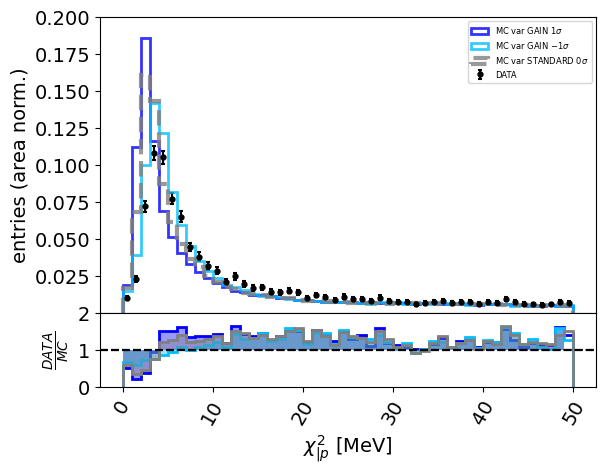

In [9]:
import math
import numpy as np
import uproot
import awkward as ak
import ROOT
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 1) Estrazione one-shot degli istogrammi PID ROOT -> array numpy
#    (va fatta UNA SOLA VOLTA, prima di qualsiasi chiamata a chi2_ALG)
# ---------------------------------------------------------------------
def hist_to_arrays(h):
    nb = h.GetNbinsX()
    content = np.array([h.GetBinContent(i) for i in range(1, nb + 1)])
    error = np.array([h.GetBinError(i) for i in range(1, nb + 1)])
    edges = np.array([h.GetBinLowEdge(i) for i in range(1, nb + 2)])  # nb+1 edges
    return content, error, edges


def fix_zero_bins(content, error):
    """Sostituisce bin con content<1e-6 con la media dei vicini (come l'originale)."""
    content = content.copy()
    error = error.copy()
    bad = np.where(content < 1e-6)[0]
    for i in bad:
        lo = max(i - 1, 0)
        hi = min(i + 1, len(content) - 1)
        content[i] = (content[lo] + content[hi]) / 2
        error[i] = (error[lo] + error[hi]) / 2
    return content, error


pro_content, pro_error, pro_edges = hist_to_arrays(dedx_range_pro)
ka_content, ka_error, ka_edges = hist_to_arrays(dedx_range_ka)
pi_content, pi_error, pi_edges = hist_to_arrays(dedx_range_pi)
mu_content, mu_error, mu_edges = hist_to_arrays(dedx_range_mu)

pro_content, pro_error = fix_zero_bins(pro_content, pro_error)
ka_content, ka_error = fix_zero_bins(ka_content, ka_error)
pi_content, pi_error = fix_zero_bins(pi_content, pi_error)
mu_content, mu_error = fix_zero_bins(mu_content, mu_error)


# ---------------------------------------------------------------------
# 2) chi2_ALG vettorizzata (nessuna chiamata ROOT dentro)
# ---------------------------------------------------------------------
def chi2_ALG(dEdx, RR, rr_min, rr_max):
    """
    Versione vettorizzata numpy di chi2_ALG.
    Ritorna [chi2mu, chi2pro, chi2ka, chi2pi] normalizzati per numero di punti usati.
    Ritorna [0,0,0,0] se non ci sono punti validi (invece di dividere per zero).
    """
    dEdx = np.asarray(dEdx, dtype=np.float64)
    RR = np.asarray(RR, dtype=np.float64)

    if len(dEdx) <= 2:
        return [0.0, 0.0, 0.0, 0.0]

    # esclude primo e ultimo punto, come nell'originale
    dEdx = dEdx[1:-1]
    RR = RR[1:-1]

    mask_rr = (RR > rr_min) & (RR < rr_max)
    trkdedx = dEdx[mask_rr]
    trkres = RR[mask_rr]

    if len(trkdedx) == 0:
        return [0.0, 0.0, 0.0, 0.0]

    valid = (trkdedx <= 100) & (trkdedx >= 0.5)
    d = trkdedx[valid]
    r = trkres[valid]

    npt = len(d)
    if npt == 0:
        return [0.0, 0.0, 0.0, 0.0]

    bin_idx = np.searchsorted(pro_edges, r, side='right') - 1
    bin_idx = np.clip(bin_idx, 0, len(pro_content) - 1)

    errdedx = (0.04231 + 0.0001783 * d * d) * d

    chi2pro = np.sum(((d - pro_content[bin_idx]) / np.sqrt(pro_error[bin_idx] ** 2 + errdedx ** 2)) ** 2)
    chi2ka = np.sum(((d - ka_content[bin_idx]) / np.sqrt(ka_error[bin_idx] ** 2 + errdedx ** 2)) ** 2)
    chi2pi = np.sum(((d - pi_content[bin_idx]) / np.sqrt(pi_error[bin_idx] ** 2 + errdedx ** 2)) ** 2)
    chi2mu = np.sum(((d - mu_content[bin_idx]) / np.sqrt(mu_error[bin_idx] ** 2 + errdedx ** 2)) ** 2)

    return [chi2mu / npt, chi2pro / npt, chi2ka / npt, chi2pi / npt]


# ---------------------------------------------------------------------
# 3) Helper: calcolo chi2 su un intero file, senza rifare slicing
#    Record awkward evento-per-evento
# ---------------------------------------------------------------------
BRANCHES = [
    "slice/_protons/_protons._dedx",
    "slice/_protons/_protons._rr",
    "slice/_mu/_mu._dedx",
    "slice/_mu/_mu._rr",
    "slice/_protons/_protons._theta_xw",
    "slice/_mu/_mu._theta_xw",
    "slice/_protons/_protons._depE",
    "slice/_mu/_mu._depE",
]


def compute_chi2_from_file(filename, particle, chi2_index):
    file = uproot.open(filename)
    tree = file['tree']
    arrays = tree.arrays(BRANCHES, library="ak")

    dedx_branch = arrays[f"slice/{particle}/{particle}._dedx"]
    rr_branch = arrays[f"slice/{particle}/{particle}._rr"]

    chi2 = []
    if particle == '_protons':
        # per ogni evento, per ogni traccia protone nell'evento
        for evt_dedx, evt_rr in zip(dedx_branch, rr_branch):
            for trk_dedx, trk_rr in zip(evt_dedx, evt_rr):
                if len(trk_dedx) > 0:
                    chi2.append(chi2_ALG(trk_dedx, trk_rr, 0, 25)[chi2_index])
    elif particle == '_mu':
        for evt_dedx, evt_rr in zip(dedx_branch, rr_branch):
            if len(evt_dedx):
                chi2.append(chi2_ALG(evt_dedx, evt_rr, 0, 25)[chi2_index])

    return chi2, tree.num_entries


# ---------------------------------------------------------------------
# 4) Script principale (stessa logica dell'originale, riorganizzata)
# ---------------------------------------------------------------------
chi2_index = 1

fig = plt.figure()
gs = fig.add_gridspec(2, 1, height_ratios=[8, 2], hspace=0)

# ---- DATA ----
print('DATA')
filename = f'varMC_DATA{cut}.root'
chi2_data, n_entries = compute_chi2_from_file(filename, particle, chi2_index)
print("num entries:", n_entries)

data_np = np.array(chi2_data)

# istogramma DATA con numpy invece di ROOT.TH1D + Fill loop
counts_DATA, bin_edges = np.histogram(data_np, bins=NBINS_CHI2, range=(0, HIGH_CHI2))
bin_centers_DATA = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_width = bin_edges[1] - bin_edges[0]
integral = np.sum(counts_DATA) * bin_width

errors_DATA = np.sqrt(counts_DATA) / integral if integral > 0 else np.zeros_like(counts_DATA)
counts_DATA = counts_DATA / integral if integral > 0 else counts_DATA.astype(float)

# ---- OFFBEAM ----
print('OFFBEAM')
filename = f'varMC_OFFBEAM{cut}.root'
chi2_OFFBEAM, _ = compute_chi2_from_file(filename, particle, chi2_index)

weights_OFFBEAM_chi2 = np.full(len(chi2_OFFBEAM), 1. / POT_OFFBEAM)

plt.subplot(gs[0])
plt.errorbar(
    bin_centers_DATA, counts_DATA, yerr=errors_DATA,
    fmt='o', ms=3.5, capsize=1.5, capthick=1.5, elinewidth=1.5,
    color='black', label='DATA'
)

# ---- MC variations ----
m = -1
for mode in mode_vars:
    for n, sigma in enumerate(['_plus1sigma', '_minus1sigma']):

        if (n == 0 and mode == 'STANDARD') or (n == 0 and mode == f'WIREMOD{cut}'):
            continue
        if (n == 1 and mode == 'STANDARD') or (n == 1 and mode == f'WIREMOD{cut}'):
            sigma = ''

        m = m + 1

        filename = f'varMC_{mode}{sigma}.root'
        print(filename)

        chi2, _ = compute_chi2_from_file(filename, particle, chi2_index)

        POT = POT_WIREMOD if mode == f"WIREMOD{cut}" else POT_MC
        weights_MC_chi2 = np.full(len(chi2), 1. / POT)

        mc_off = np.concatenate([chi2, chi2_OFFBEAM])
        weights_mc_off = np.concatenate([weights_MC_chi2, weights_OFFBEAM_chi2])

        n_mc_off, bins = np.histogram(
            mc_off,
            bins=NBINS_CHI2,
            range=(0, HIGH_CHI2),
            weights=weights_mc_off,
            density=True
        )

        bin_centers = 0.5 * (bins[:-1] + bins[1:])

        ratio = np.zeros_like(counts_DATA)
        nonzero = n_mc_off > 0
        ratio[nonzero] = counts_DATA[nonzero] / n_mc_off[nonzero]

        sigma_n = 0
        if sigma == '_plus1sigma':
            sigma_n = 1
        elif sigma == '_minus1sigma':
            sigma_n = -1

        plt.subplot(gs[0])

        lls = "-"
        llw = 2
        if mode == 'STANDARD':
            lls = '--'
            llw = 3

        plt.hist(
            mc_off, bins=NBINS_CHI2, range=(0, HIGH_CHI2), weights=weights_mc_off,
            density=True, histtype='step', lw=llw, ls=lls,
            label=fr'MC var {mode} ${sigma_n}\sigma$', color=var_color[m], alpha=0.8
        )
        plt.setp(plt.gca().get_xticklabels(), visible=False)
        plt.gca().tick_params(labelbottom=False)
        ax = plt.gca()
        yticks = ax.get_yticks()
        ax.set_yticks(yticks[yticks > ax.get_ylim()[0]])
        plt.ylabel('entries (area norm.)', fontsize=14)
        plt.yticks(fontsize=14)

        plt.subplot(gs[1])

        dx = bin_centers[1] - bin_centers[0]
        edges = np.concatenate([
            [bin_centers[0] - dx / 2],
            bin_centers[:-1] + dx / 2,
            [bin_centers[-1] + dx / 2]
        ])

        plt.stairs(ratio, edges, fill=False, lw=2, color=var_color[m])
        plt.fill_between(
            edges[:-1], 1, ratio, step='post', alpha=0.4, color=var_color[m], lw=0
        )
        plt.axhline(1.0, color='black', linestyle='--')

        which_chi2 = r'$\chi^2_{|\mu}$' if chi2_index == 0 else r'$\chi^2_{|p}$'
        plt.xlabel(fr'{which_chi2} [MeV]', fontsize=14)
        plt.ylabel(r'$\frac{DATA}{MC}$', fontsize=14)
        plt.xticks(fontsize=14, rotation=60)
        plt.yticks(fontsize=14)
        plt.ylim(0, 2)

plt.subplot(gs[0])
plt.legend(loc='upper right', fontsize=6, ncols=1)
plt.savefig(f'DEDX_VAR/chi2_{chi2_index}_{particle}_WIREMOD{cut}.pdf', format='pdf', bbox_inches='tight')